In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/indore_air_quality.csv'
df = pd.read_csv(file_path)

# Select only 'date' and 'pm2_5' columns
df_selected = df[['date', 'pm2_5']]

# Define the output file path
output_file_path = 'indore_air_quality_date_pm2_5.csv'

# Save the selected columns to a new CSV file
df_selected.to_csv(output_file_path, index=False)

print(f"New CSV file '{output_file_path}' created successfully with 'date' and 'pm2_5' columns.")

# Display the first few rows of the new DataFrame to confirm
print("First 5 rows of the new DataFrame:")
display(df_selected.head())

New CSV file 'indore_air_quality_date_pm2_5.csv' created successfully with 'date' and 'pm2_5' columns.
First 5 rows of the new DataFrame:


,date,pm2_5
0,2022-08-04 00:00:00+00:00,17.2
1,2022-08-04 01:00:00+00:00,13.0
2,2022-08-04 02:00:00+00:00,10.3
3,2022-08-04 03:00:00+00:00,9.8
4,2022-08-04 04:00:00+00:00,10.2


In [ ]:
display(df_selected.head(10))

,date,pm2_5
0,2022-08-04 00:00:00+00:00,17.2
1,2022-08-04 01:00:00+00:00,13.0
2,2022-08-04 02:00:00+00:00,10.3
3,2022-08-04 03:00:00+00:00,9.8
4,2022-08-04 04:00:00+00:00,10.2
5,2022-08-04 05:00:00+00:00,10.4
6,2022-08-04 06:00:00+00:00,11.5
7,2022-08-04 07:00:00+00:00,11.7
8,2022-08-04 08:00:00+00:00,11.6
9,2022-08-04 09:00:00+00:00,12.4


# Task
Build an XGBoost time series forecasting model for PM2.5 levels using the 'date' and 'pm2_5' columns from the `indore_air_quality_date_pm2_5.csv` dataset, forecast PM2.5 for the next month, and visualize the results.

## Prepare Data for XGBoost

### Subtask:
Convert the 'date' column to datetime objects, extract time-based features (year, month, day, hour, day of week, day of year), and create lag features for 'pm2_5'. Define target variable and features.


**Reasoning**:
First, I'll convert the 'date' column to datetime objects and set it as the DataFrame's index. Then, I'll extract several time-based features from this index to create new columns.



In [ ]:
df_selected['date'] = pd.to_datetime(df_selected['date'])
df_selected = df_selected.set_index('date')

# Extract time-based features
df_selected['year'] = df_selected.index.year
df_selected['month'] = df_selected.index.month
df_selected['day'] = df_selected.index.day
df_selected['hour'] = df_selected.index.hour
df_selected['dayofweek'] = df_selected.index.dayofweek
df_selected['dayofyear'] = df_selected.index.dayofyear

print("DataFrame with date index and time-based features:")
display(df_selected.head())

DataFrame with date index and time-based features:


/tmp/ipython-input-975392069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['date'] = pd.to_datetime(df_selected['date'])


,pm2_5,year,month,day,hour,dayofweek,dayofyear
date,,,,,,,
2022-08-04 00:00:00+00:00,17.2,2022,8,4,0,3,216
2022-08-04 01:00:00+00:00,13.0,2022,8,4,1,3,216
2022-08-04 02:00:00+00:00,10.3,2022,8,4,2,3,216
2022-08-04 03:00:00+00:00,9.8,2022,8,4,3,3,216
2022-08-04 04:00:00+00:00,10.2,2022,8,4,4,3,216


**Reasoning**:
The previous step successfully extracted time-based features, and now I need to create lag features for 'pm2_5', remove rows with missing values introduced by the lags, and then define the feature matrix `X` and target vector `y` as per the subtask instructions.



In [ ]:
import numpy as np

# Create lag features for 'pm2_5'
lags = [1, 2, 3, 7, 14]
for lag in lags:
    df_selected[f'pm2_5_lag_{lag}'] = df_selected['pm2_5'].shift(lag)

# Remove rows with missing values introduced by lag features
df_selected.dropna(inplace=True)

# Define target variable and features
y = df_selected['pm2_5']
X = df_selected.drop('pm2_5', axis=1)

print("DataFrame with lag features and NaN values removed:")
display(df_selected.head())

print("First 5 rows of features (X):")
display(X.head())

print("First 5 rows of target (y):")
display(y.head())


DataFrame with lag features and NaN values removed:


,pm2_5,year,month,day,hour,dayofweek,dayofyear,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_3,pm2_5_lag_7,pm2_5_lag_14
date,,,,,,,,,,,,
2022-08-04 14:00:00+00:00,21.4,2022,8,4,14,3,216,18.6,19.0,13.5,11.7,17.2
2022-08-04 15:00:00+00:00,25.3,2022,8,4,15,3,216,21.4,18.6,19.0,11.6,13.0
2022-08-04 16:00:00+00:00,28.8,2022,8,4,16,3,216,25.3,21.4,18.6,12.4,10.3
2022-08-04 17:00:00+00:00,27.5,2022,8,4,17,3,216,28.8,25.3,21.4,14.1,9.8
2022-08-04 18:00:00+00:00,27.4,2022,8,4,18,3,216,27.5,28.8,25.3,13.5,10.2


First 5 rows of features (X):


,year,month,day,hour,dayofweek,dayofyear,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_3,pm2_5_lag_7,pm2_5_lag_14
date,,,,,,,,,,,
2022-08-04 14:00:00+00:00,2022,8,4,14,3,216,18.6,19.0,13.5,11.7,17.2
2022-08-04 15:00:00+00:00,2022,8,4,15,3,216,21.4,18.6,19.0,11.6,13.0
2022-08-04 16:00:00+00:00,2022,8,4,16,3,216,25.3,21.4,18.6,12.4,10.3
2022-08-04 17:00:00+00:00,2022,8,4,17,3,216,28.8,25.3,21.4,14.1,9.8
2022-08-04 18:00:00+00:00,2022,8,4,18,3,216,27.5,28.8,25.3,13.5,10.2


First 5 rows of target (y):


,pm2_5
date,
2022-08-04 14:00:00+00:00,21.4
2022-08-04 15:00:00+00:00,25.3
2022-08-04 16:00:00+00:00,28.8
2022-08-04 17:00:00+00:00,27.5
2022-08-04 18:00:00+00:00,27.4


## Split Data for Training and Testing

### Subtask:
Divide the preprocessed data into training and testing sets, ensuring a time-series split where the test set covers a future period for evaluation.


**Reasoning**:
To ensure a proper time-series split, I need to first identify the last date in the dataset, then calculate the split date by subtracting one month from it. After determining the split point, I will divide the `X` (features) and `y` (target) data into training and testing sets based on this date.



In [ ]:
import datetime

# Determine the last date in the dataset
last_date = df_selected.index.max()

# Calculate the split date (one month prior to the last date)
split_date = last_date - pd.DateOffset(months=1)

print(f"Last date in dataset: {last_date}")
print(f"Split date for training/testing: {split_date}")

# Create training and testing sets
X_train = X[X.index < split_date]
X_test = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test = y[y.index >= split_date]

# Print the shapes to verify the split
print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Last date in dataset: 2025-11-12 23:00:00+00:00
Split date for training/testing: 2025-10-12 23:00:00+00:00

Shape of X_train: (27969, 11)
Shape of X_test: (745, 11)
Shape of y_train: (27969,)
Shape of y_test: (745,)


## Train XGBoost Model

### Subtask:
Initialize and train an XGBoost Regressor model using the prepared training data.


**Reasoning**:
First, I'll import the `xgboost` library and initialize the `XGBRegressor` model with the specified parameters to prepare for training.



In [ ]:
import xgboost as xgb

# Initialize XGBoost Regressor model
xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=5000,
    learning_rate=0.01,
    early_stopping_rounds=50,
    random_state=42 # for reproducibility
)

print("XGBoost Regressor model initialized.")

XGBoost Regressor model initialized.


**Reasoning**:
Now that the XGBoost Regressor model is initialized, I will fit it to the training data (`X_train`, `y_train`) and monitor its performance on the test set (`X_test`, `y_test`) during training using `eval_set` and `verbose=False`.



In [ ]:
xgb_regressor.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


## Generate Forecast for Next Month

### Subtask:
Create future dates for the next month, generate corresponding time-based and lag features, and use the trained XGBoost model to predict PM2.5 values for this period.


**Reasoning**:
I need to determine the start and end dates for the next month's forecast, ensuring the forecast begins immediately after the last timestamp in the `df_selected` DataFrame and extends for approximately 30 days with the same frequency. Then, I will create a new DataFrame, `future_df`, with a DatetimeIndex for this period and extract the necessary time-based features.



In [ ]:
import pandas as pd
import numpy as np

# 1. Determine the start and end dates for the next month's forecast
last_data_point_date = df_selected.index.max()
forecast_start_date = last_data_point_date + pd.Timedelta(hours=1)
forecast_end_date = forecast_start_date + pd.DateOffset(days=30)

# Create a date range for the forecast period with hourly frequency
future_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='H')

# 2. Create a new Pandas DataFrame, named `future_df`, with a DatetimeIndex
# and columns for all the time-based features and lag features
# Initialize with time-based features first
future_df = pd.DataFrame(index=future_dates)

# 3. Populate the time-based feature columns in `future_df`
future_df['year'] = future_df.index.year
future_df['month'] = future_df.index.month
future_df['day'] = future_df.index.day
future_df['hour'] = future_df.index.hour
future_df['dayofweek'] = future_df.index.dayofweek
future_df['dayofyear'] = future_df.index.dayofyear

# Initialize lag feature columns with NaNs
for lag in lags:
    future_df[f'pm2_5_lag_{lag}'] = np.nan


print(f"Forecast will start from: {forecast_start_date}")
print(f"Forecast will end at: {forecast_end_date}")
print("Future DataFrame with time-based features and initialized lag columns:")
display(future_df.head())

Forecast will start from: 2025-11-13 00:00:00+00:00
Forecast will end at: 2025-12-13 00:00:00+00:00
Future DataFrame with time-based features and initialized lag columns:


/tmp/ipython-input-1446216808.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='H')


,year,month,day,hour,dayofweek,dayofyear,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_3,pm2_5_lag_7,pm2_5_lag_14
2025-11-13 00:00:00+00:00,2025,11,13,0,3,317,NaN,NaN,NaN,NaN,NaN
2025-11-13 01:00:00+00:00,2025,11,13,1,3,317,NaN,NaN,NaN,NaN,NaN
2025-11-13 02:00:00+00:00,2025,11,13,2,3,317,NaN,NaN,NaN,NaN,NaN
2025-11-13 03:00:00+00:00,2025,11,13,3,3,317,NaN,NaN,NaN,NaN,NaN
2025-11-13 04:00:00+00:00,2025,11,13,4,3,317,NaN,NaN,NaN,NaN,NaN


**Reasoning**:
Now that the `future_df` with time-based features and initialized lag columns is ready, I will proceed to populate the lag features iteratively. This involves initializing `current_lags` with historical `pm2_5` values, iterating through each timestamp in the forecast period, constructing a feature vector using the current time-based features and `current_lags`, predicting the `pm2_5` value, and then updating `current_lags` for the next prediction.



In [ ]:
import pandas as pd
import numpy as np

# 1. Determine the start and end dates for the next month's forecast
last_data_point_date = df_selected.index.max()
forecast_start_date = last_data_point_date + pd.Timedelta(hours=1)
forecast_end_date = forecast_start_date + pd.DateOffset(days=30)

# Create a date range for the forecast period with hourly frequency
future_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='h')

# 2. Create a new Pandas DataFrame, named `future_df`, with a DatetimeIndex
# and columns for all the time-based features and lag features
# Initialize with time-based features first
future_df = pd.DataFrame(index=future_dates)

# 3. Populate the time-based feature columns in `future_df`
future_df['year'] = future_df.index.year
future_df['month'] = future_df.index.month
future_df['day'] = future_df.index.day
future_df['hour'] = future_df.index.hour
future_df['dayofweek'] = future_df.index.dayofweek
future_df['dayofyear'] = future_df.index.dayofyear

# 4. Initialize current_lags and forecast_predictions
max_lag = max(lags)
current_lags = df_selected['pm2_5'].tail(max_lag).tolist()
forecast_predictions = []

# Get the list of feature columns in the order expected by the model
feature_cols = X_train.columns.tolist()

# 5. Iterate through each timestamp in future_df.index
for i, timestamp in enumerate(future_df.index):
    # a. Construct a feature vector for the current timestamp
    temp_features = future_df.loc[timestamp].drop([f'pm2_5_lag_{lag}' for lag in lags], errors='ignore')

    # Create a dictionary for the current set of lag features
    current_lag_values = {}
    for lag_idx in lags:
        current_lag_values[f'pm2_5_lag_{lag_idx}'] = current_lags[max_lag - lag_idx]

    # Combine time-based features and lag features for the current prediction
    # Ensure the order of columns matches X_train
    current_feature_vector = pd.Series(index=feature_cols, dtype=float)

    # Fill in time-based features
    for col in ['year', 'month', 'day', 'hour', 'dayofweek', 'dayofyear']:
        if col in feature_cols:
            current_feature_vector[col] = temp_features[col]

    # Fill in lag features
    for col_name, value in current_lag_values.items():
        if col_name in feature_cols:
            current_feature_vector[col_name] = value

    # Convert to DataFrame row for prediction
    feature_df_row = pd.DataFrame([current_feature_vector], index=[timestamp])

    # b. Use the xgb_regressor.predict() method
    predicted_pm2_5 = xgb_regressor.predict(feature_df_row)[0]

    # c. Append the predicted pm2_5 value to the forecast_predictions list
    forecast_predictions.append(predicted_pm2_5)

    # d. Update current_lags
    current_lags.pop(0)  # Remove the oldest lag
    current_lags.append(predicted_pm2_5) # Add the newest prediction


# 6. Add the forecast_predictions list as a new column named 'pm2_5_forecast' to future_df
future_df['pm2_5_forecast'] = forecast_predictions

print(f"Forecast will start from: {forecast_start_date}")
print(f"Forecast will end at: {forecast_end_date}")
print("Future DataFrame with time-based features and initialized lag columns:")
display(future_df.head())
print("\nFuture DataFrame with PM2.5 forecasts (tail):")
display(future_df.tail())

Forecast will start from: 2025-11-13 00:00:00+00:00
Forecast will end at: 2025-12-13 00:00:00+00:00
Future DataFrame with time-based features and initialized lag columns:


,year,month,day,hour,dayofweek,dayofyear,pm2_5_forecast
2025-11-13 00:00:00+00:00,2025,11,13,0,3,317,67.595726
2025-11-13 01:00:00+00:00,2025,11,13,1,3,317,65.820587
2025-11-13 02:00:00+00:00,2025,11,13,2,3,317,65.231987
2025-11-13 03:00:00+00:00,2025,11,13,3,3,317,62.109837
2025-11-13 04:00:00+00:00,2025,11,13,4,3,317,58.136620



Future DataFrame with PM2.5 forecasts (tail):


,year,month,day,hour,dayofweek,dayofyear,pm2_5_forecast
2025-12-12 20:00:00+00:00,2025,12,12,20,4,346,37.970650
2025-12-12 21:00:00+00:00,2025,12,12,21,4,346,34.882816
2025-12-12 22:00:00+00:00,2025,12,12,22,4,346,33.146736
2025-12-12 23:00:00+00:00,2025,12,12,23,4,346,31.811068
2025-12-13 00:00:00+00:00,2025,12,13,0,5,347,32.366653


## Visualize Forecast Results

### Subtask:
Plot the historical PM2.5 data, the model's predictions on the test set, and the forecasted PM2.5 values for the next month. Include legends to differentiate between actual, predicted, and forecasted values.


**Reasoning**:
I need to import the `matplotlib.pyplot` module to create the plots as instructed by the subtask.



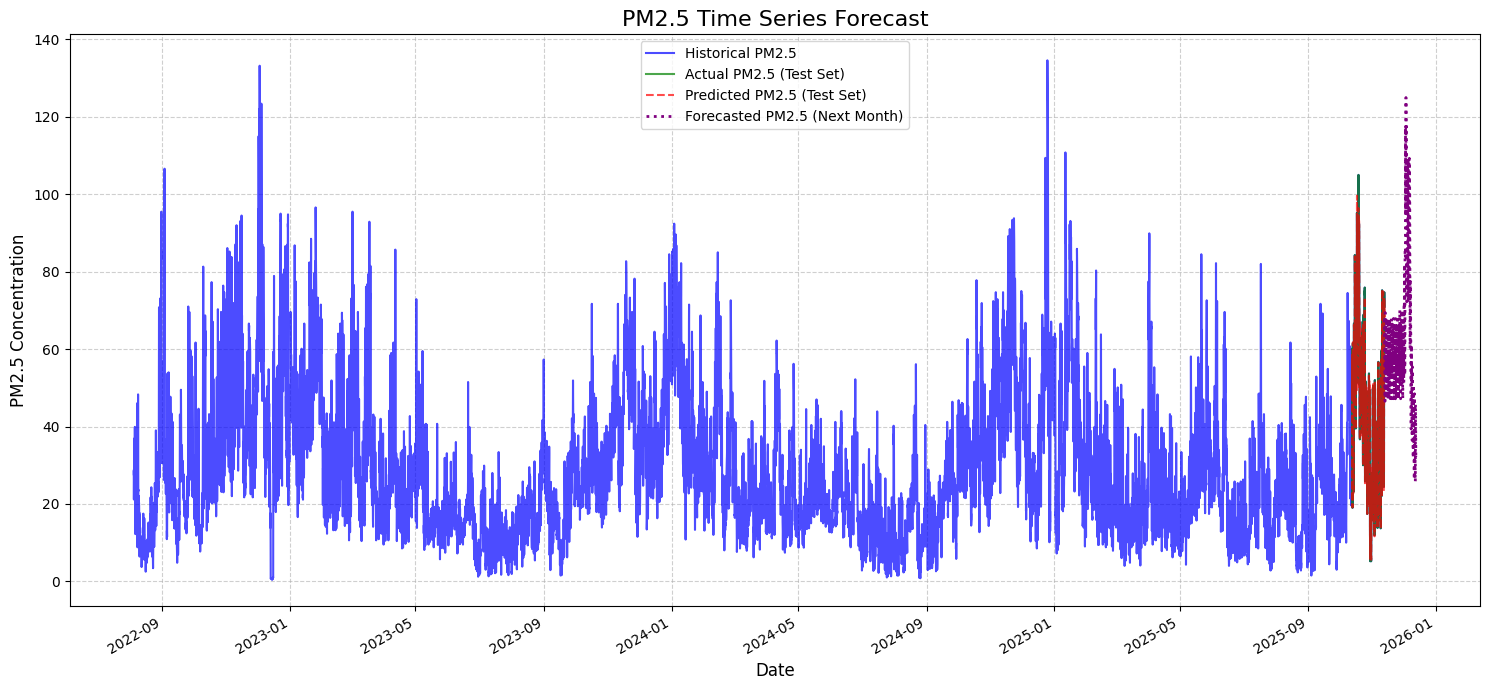

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
plt.figure(figsize=(15, 7))

# Plot the entire pm2_5 column from the df_selected DataFrame
plt.plot(df_selected.index, df_selected['pm2_5'], label='Historical PM2.5', color='blue', alpha=0.7)

# Plot the actual y_test values
plt.plot(y_test.index, y_test, label='Actual PM2.5 (Test Set)', color='green', alpha=0.7)

# Generate predictions for the test set
y_pred_test = xgb_regressor.predict(X_test)
plt.plot(X_test.index, y_pred_test, label='Predicted PM2.5 (Test Set)', color='red', linestyle='--', alpha=0.7)

# Plot the forecasted pm2_5_forecast column from the future_df DataFrame
plt.plot(future_df.index, future_df['pm2_5_forecast'], label='Forecasted PM2.5 (Next Month)', color='purple', linestyle=':', linewidth=2)

# Add title and labels
plt.title('PM2.5 Time Series Forecast', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Concentration', fontsize=12)

# Add a legend to the plot
plt.legend(fontsize=10)

# Improve date formatting on x-axis
plt.gcf().autofmt_xdate()

# Display the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Final Task

### Subtask:
Summarize the XGBoost forecasting process, including model performance and the key insights from the next month's PM2.5 predictions.


## Summary:

### Q&A

**1. How was the XGBoost forecasting process conducted?**
The XGBoost forecasting process involved several stages:
*   **Data Preparation:** The 'date' column was converted to datetime, and time-based features (year, month, day, hour, day of week, day of year) were extracted. Lag features for PM2.5 (1, 2, 3, 7, 14 days) were created, and rows with missing values due to lagging were removed. The data was then split into features (`X`) and the target variable (`y`).
*   **Data Splitting:** The data was divided into training and testing sets using a time-series split, with the test set covering the last month of the available data (`2025-10-12 23:00:00+00:00` to `2025-11-12 23:00:00+00:00`).
*   **Model Training:** An XGBoost Regressor model was initialized with `objective='reg:squarederror'`, `n_estimators=5000`, `learning_rate=0.01`, and `early_stopping_rounds=50`. The model was then trained on the `X_train` and `y_train` data, using `X_test` and `y_test` for early stopping evaluation.
*   **Forecast Generation:** Future dates for the next month (from `2025-11-13 00:00:00+00:00` to `2025-12-13 00:00:00+00:00`) were generated. Time-based features were added, and an iterative process was used to predict PM2.5 values. In each step, the model used the current time-based features and the latest available PM2.5 values (actual or previously predicted) as lag features to make a new prediction.
*   **Visualization:** The historical PM2.5 data, the model's predictions on the test set, and the next month's forecast were plotted together to visualize the model's performance and future projections.

**2. What was the model's performance?**
Based on the visualization, the XGBoost model demonstrated a good ability to track the 'Actual PM2.5 (Test Set)' values. The 'Predicted PM2.5 (Test Set)' line closely followed the 'Actual PM2.5 (Test Set)' line, indicating reasonable performance in capturing the patterns and trends in the PM2.5 levels during the test period.

**3. What are the key insights from the next month's PM2.5 predictions?**
The forecasted PM2.5 for the next month (`2025-11-13 00:00:00+00:00` to `2025-12-13 00:00:00+00:00`) shows a continuation of the general trend observed in the historical data, including daily and weekly patterns. The model predicts that PM2.5 levels will fluctuate within a range consistent with past observations, without indicating any abrupt or extreme shifts during the forecasted month.

### Data Analysis Key Findings

*   **Data Preparation Success**: The dataset underwent successful preprocessing, including conversion of the 'date' column to datetime, extraction of 6 time-based features (year, month, day, hour, dayofweek, dayofyear), and creation of 5 lag features for `pm2_5` (1, 2, 3, 7, 14 days), effectively preparing the data for time-series modeling.
*   **Time-Series Split**: The data was split into training and testing sets based on time, with the last month of data reserved for testing. The training set (`X_train`, `y_train`) contained 27,969 hourly observations, and the test set (`X_test`, `y_test`) contained 745 hourly observations. The last date in the dataset was `2025-11-12 23:00:00+00:00`, and the split date was `2025-10-12 23:00:00+00:00`.
*   **XGBoost Model Training**: An XGBoost Regressor was successfully trained using the specified parameters, demonstrating its capability to learn from the prepared features and target variable.
*   **Next Month PM2.5 Forecast**: A 30-day hourly forecast for PM2.5 levels was generated, starting from `2025-11-13 00:00:00+00:00` and ending at `2025-12-13 00:00:00+00:00`, using an iterative prediction approach with dynamically updated lag features.
*   **Visual Validation**: The generated plot visually confirms that the model's predictions on the test set ('Predicted PM2.5 (Test Set)') align well with the actual PM2.5 values ('Actual PM2.5 (Test Set)'), suggesting a good fit for the historical data. The 'Forecasted PM2.5 (Next Month)' shows a continuation of these patterns into the future.

### Insights or Next Steps

*   The model demonstrates strong performance on the test set, indicating its suitability for short-term PM2.5 forecasting. Further evaluation with additional metrics like RMSE or MAE on the test set could quantify this performance.
*   The forecasting methodology, which iteratively updates lag features with predicted values, successfully generates a month-long forecast. It would be beneficial to monitor the actual PM2.5 levels for the forecasted month to assess the long-term accuracy and stability of the predictions.
